In [65]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
try:
    import torch
except ModuleNotFoundError:
    torch = None

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_curve_run,
    postprocess_curve_run_overview,
    display_curve_run_overview,
    postprocess_build_active_curve_diagnostics,
    curve_summary_table,
    print_curve_diagnostics,
    display_curve_main_dashboard,
    display_curve_pointwise_summary,
    display_curve_sample_error_summary,
    display_curve_peak_energy_summary,
    display_curve_zone_summary,
    display_curve_sample_examples,
    display_curve_loss_component_breakdown,
    plot_curve_all_point_parity,
    display_curve_initial_slope_summary,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [66]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Find Recent Runs


In [67]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")
MAX_RECENT_RUNS = 25


if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=MAX_RECENT_RUNS, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")


## 2. User Configuration


In [68]:
mechMode = "FT"
output_kind = "FieldToCurve"
model = "Transformer"
run_name = "Field2Curve-FTfull-test"
VIEW_MODE = "FT"
run_type = "standard"  # "standard", "model_hpo", or "cross_model_hpo"
RUN_PATH_OVERRIDE = None


if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / "HPO" / run_name
elif run_type == "cross_model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'cross_model_hpo'.")

DATA_PATH_OVERRIDE = None
PREFER_HPO_BEST = True
ZONE_BOUNDARIES = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

LOAD_DATA = False
LOAD_MODEL = False
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

ACTIVE_SPLIT = "val"


## 3. Load Run Artifacts


In [69]:
ARTIFACT_TABLE_KEYS = None


artifacts, loaded, DAT, MOD = postprocess_load_curve_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    prefer_hpo_best=PREFER_HPO_BEST,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts, keys=ARTIFACT_TABLE_KEYS))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


,artifact,path_or_value
0,input_path,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
1,run_dir,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
2,model_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
3,model_mdl,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
4,data_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
5,results_dir,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
6,metrics_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
7,predictions_npz,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
8,loss_history_csv,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...
9,diagnostics_summary_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...


## 4. Run Setup And Available Outputs


In [70]:
SHOW_RUN_OVERVIEW = True


overview = postprocess_curve_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_curve_evals = overview["available_curve_evals"]
ACTIVE_SPLIT = overview["active_split"]

if SHOW_RUN_OVERVIEW:
    display_curve_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


,item,value
0,run,Field2Curve-FTfull-test
1,run_type,standard
2,mechMode,FT
3,VIEW_MODE,FT
4,model,Transformer
5,output_kind,fieldtocurve
6,device,cpu
7,evaluation_split,val
8,is_hpo,False
9,model_json,Z:\p2\FT\FieldToCurve\Transformer\Field2Curve-...


### Saved Metrics For Active View

,metric,value
0,FT_best_epoch,5
1,FT_best_loss,5.720411
2,FT_best_mse,2.145383
3,FT_best_rmse,"[False, 1.4647127584466166]"


### Available Curve Predictions / Diagnostic Tables

,mode,split,outputs,truth,sample_metrics,point_metrics,zone_metrics
0,FT,val,True,True,True,True,True


No HPO files were found for this run.
mechMode: FT
VIEW_MODE: FT
ACTIVE_SPLIT: val


## 5. Build Active Curve Diagnostics


In [71]:
PRINT_ACTIVE_DIAGNOSTICS = True


diagnostics, active_key, active_diag = postprocess_build_active_curve_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
    zone_boundaries=ZONE_BOUNDARIES,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
elif PRINT_ACTIVE_DIAGNOSTICS:
    print_curve_diagnostics(active_diag, label=f"{active_key[0]} {active_key[1]}")


FT VAL prediction diagnostics | collapse ratio: 0 | RMSE: 1.558e+04 | mean-curve RMSE: 1.378e+04 | skill vs mean curve: -0.131 | peak corr: n/a | energy corr: n/a | sample curve corr: 0.908
FT VAL zones | elastic: collapse 0, RMSE 7919 | peak_region: collapse 0, RMSE 1.958e+04 | post_peak: collapse 0, RMSE 1.895e+04


## 6. Active Diagnostic Summary


In [72]:
SUMMARY_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "r2_global",
    "collapse_ratio",
    "mean_curve_baseline_rmse",
    "skill_vs_mean_curve_rmse",
    "mean_sample_curve_corr",
    "peak_corr",
    "peak_x_corr",
    "energy_corr",
    "n_samples",
    "n_points",
]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    display(curve_summary_table(active_diag, metrics=SUMMARY_METRICS))


,metric,value
0,rmse,1.558384e+04
1,mae,1.262020e+04
2,mse,2.428562e+08
3,bias,-1.261335e+04
4,r2_global,4.697474e-01
5,collapse_ratio,0.000000e+00
6,mean_curve_baseline_rmse,1.377502e+04
7,skill_vs_mean_curve_rmse,-1.313122e-01
8,mean_sample_curve_corr,9.079448e-01
9,peak_corr,NaN


## 7. Main Curve Diagnostic Dashboard


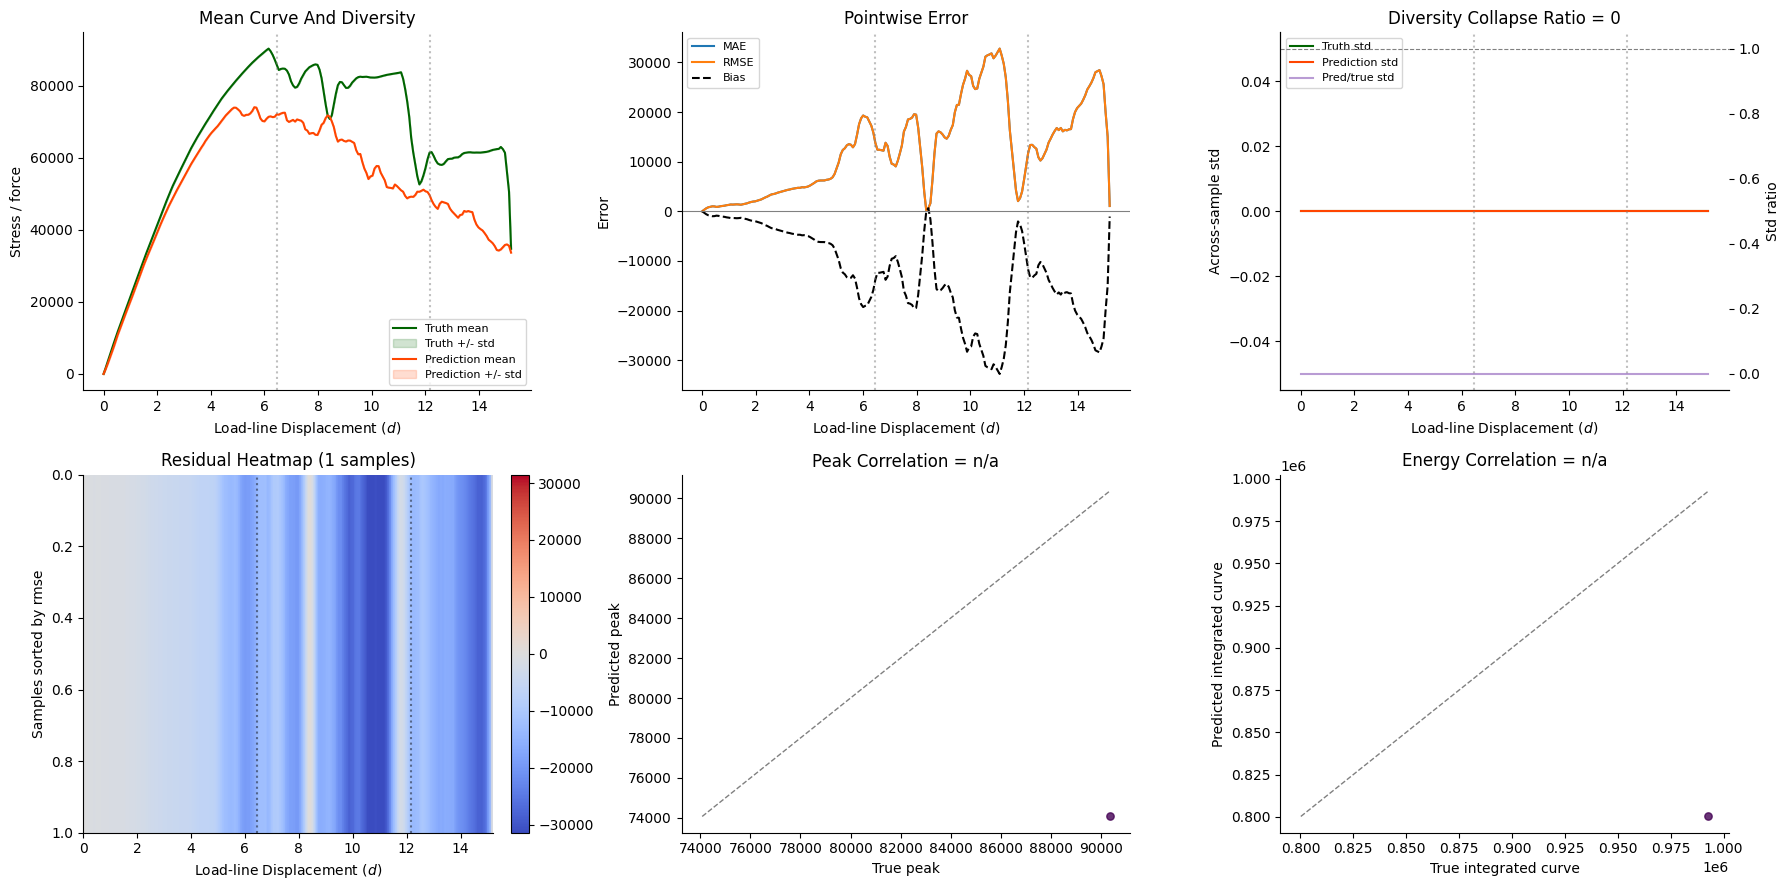

(<Figure size 1800x900 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Curve And Diversity'}, xlabel='Load-line Displacement ($d$)', ylabel='Stress / force'>,
         <Axes: title={'center': 'Pointwise Error'}, xlabel='Load-line Displacement ($d$)', ylabel='Error'>,
         <Axes: title={'center': 'Diversity Collapse Ratio = 0'}, xlabel='Load-line Displacement ($d$)', ylabel='Across-sample std'>],
        [<Axes: title={'center': 'Residual Heatmap (1 samples)'}, xlabel='Load-line Displacement ($d$)', ylabel='Samples sorted by rmse'>,
         <Axes: title={'center': 'Peak Correlation = n/a'}, xlabel='True peak', ylabel='Predicted peak'>,
         <Axes: title={'center': 'Energy Correlation = n/a'}, xlabel='True integrated curve', ylabel='Predicted integrated curve'>]],
       dtype=object))

In [73]:
DASHBOARD_MAX_SAMPLES = 64
DASHBOARD_SORT_BY = "rmse"


display_curve_main_dashboard(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_samples=DASHBOARD_MAX_SAMPLES,
    sort_by=DASHBOARD_SORT_BY,
)


## 8. Pointwise Error And Correlations


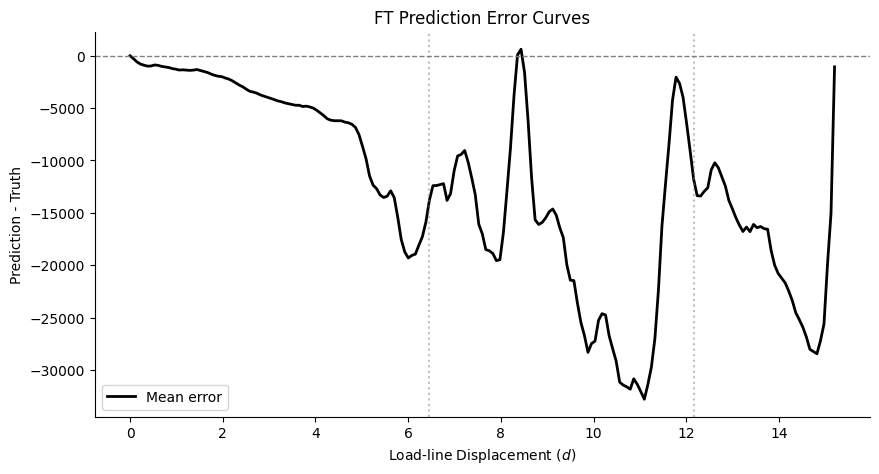

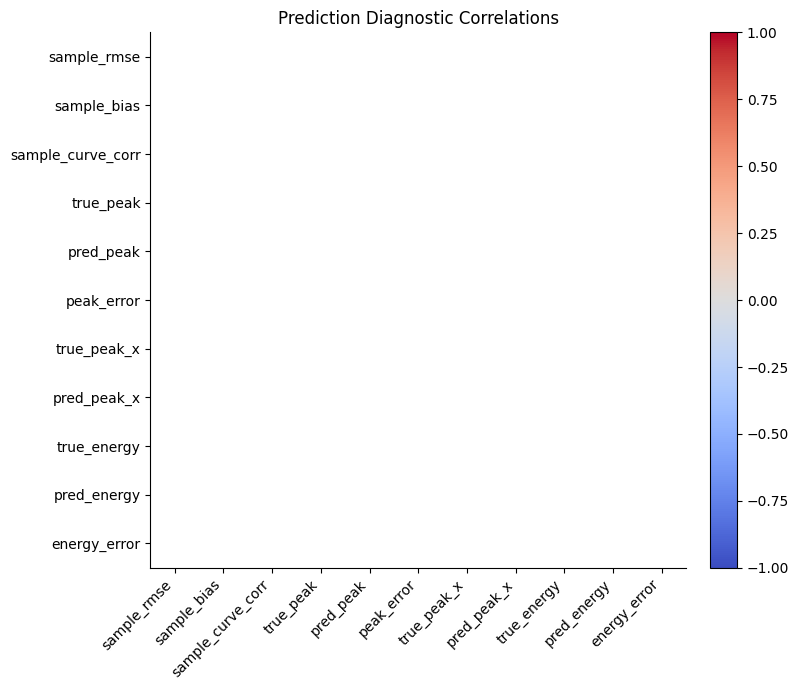

### Diagnostic Correlations

,sample_rmse,sample_bias,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,true_energy,pred_energy,energy_error
sample_rmse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_bias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_curve_corr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_peak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_peak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_error,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_peak_x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_peak_x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


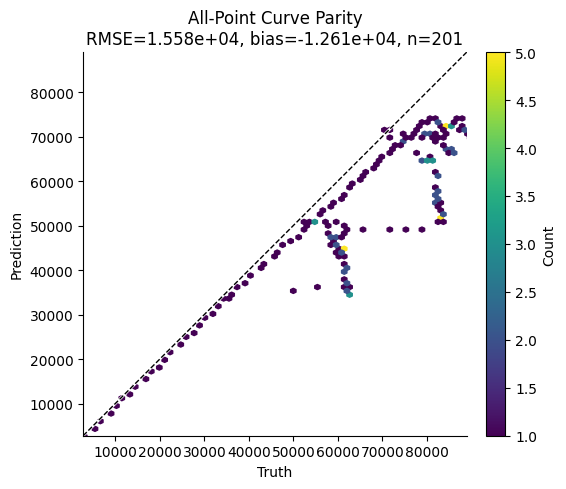

In [74]:
ERROR_CURVE_SAMPLES = 100
ERROR_CURVE_SORT_BY = "rmse"
SHOW_CORRELATION_MATRIX = True
SHOW_CURVE_PARITY = True
CURVE_PARITY_GRIDSIZE = 75
CURVE_PARITY_FIGSIZE = (6, 5)


display_curve_pointwise_summary(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_error_curves=ERROR_CURVE_SAMPLES,
    sort_by=ERROR_CURVE_SORT_BY,
    show_correlation=SHOW_CORRELATION_MATRIX,
)

if SHOW_CURVE_PARITY:
    plot_curve_all_point_parity(
        active_diag,
        gridsize=CURVE_PARITY_GRIDSIZE,
        figsize=CURVE_PARITY_FIGSIZE,
    )


## 9. Sample-Level Error


### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,sample_max_abs_error,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,peak_x_error,true_energy,pred_energy,energy_error
0,0,12620.198843,2.428562e+08,15583.842709,-12613.353,32784.642279,0.907945,90352.035989,74073.259409,-16278.77658,6.156392,5.624394,-0.531998,992827.921402,800186.350151,-192641.57125


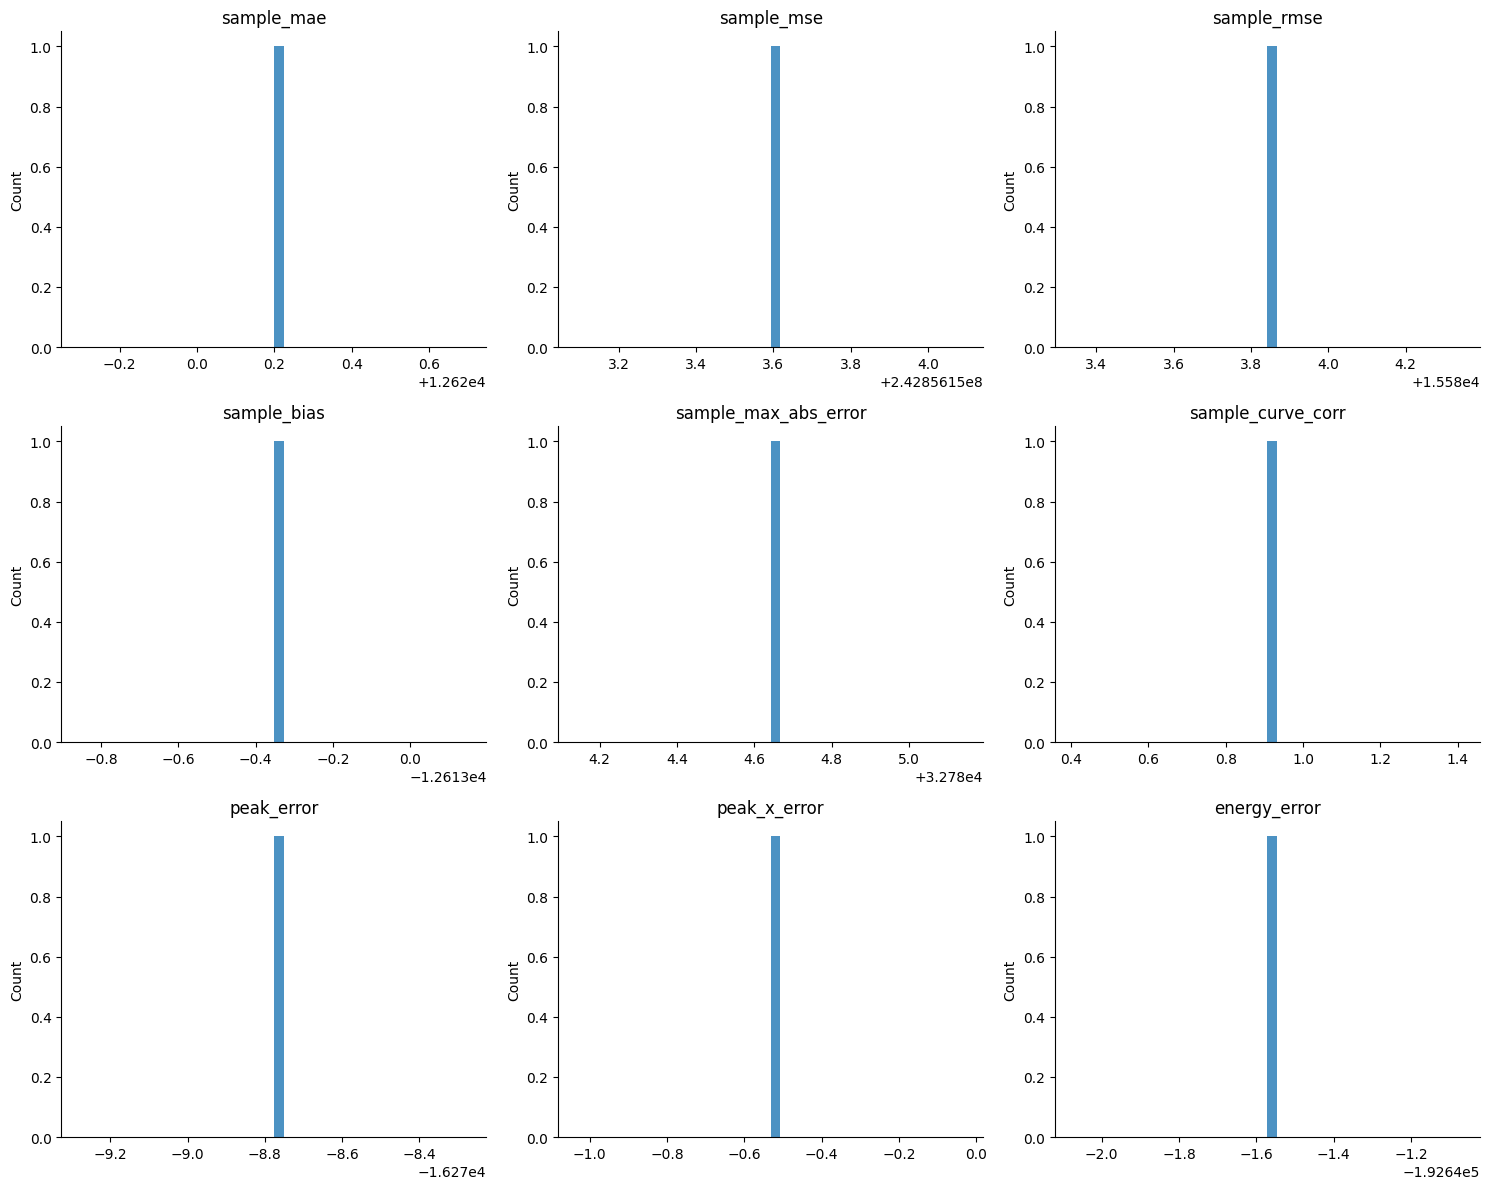

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,1.0,1.262020e+04,NaN,1.262020e+04,1.262020e+04,1.262020e+04,1.262020e+04,1.262020e+04
sample_mse,1.0,2.428562e+08,NaN,2.428562e+08,2.428562e+08,2.428562e+08,2.428562e+08,2.428562e+08
sample_rmse,1.0,1.558384e+04,NaN,1.558384e+04,1.558384e+04,1.558384e+04,1.558384e+04,1.558384e+04
sample_bias,1.0,-1.261335e+04,NaN,-1.261335e+04,-1.261335e+04,-1.261335e+04,-1.261335e+04,-1.261335e+04
sample_max_abs_error,1.0,3.278464e+04,NaN,3.278464e+04,3.278464e+04,3.278464e+04,3.278464e+04,3.278464e+04
sample_curve_corr,1.0,9.079448e-01,NaN,9.079448e-01,9.079448e-01,9.079448e-01,9.079448e-01,9.079448e-01
peak_error,1.0,-1.627878e+04,NaN,-1.627878e+04,-1.627878e+04,-1.627878e+04,-1.627878e+04,-1.627878e+04
peak_x_error,1.0,-5.319977e-01,NaN,-5.319977e-01,-5.319977e-01,-5.319977e-01,-5.319977e-01,-5.319977e-01
energy_error,1.0,-1.926416e+05,NaN,-1.926416e+05,-1.926416e+05,-1.926416e+05,-1.926416e+05,-1.926416e+05


In [75]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = [
    "sample_mae",
    "sample_mse",
    "sample_rmse",
    "sample_bias",
    "sample_max_abs_error",
    "sample_curve_corr",
    "peak_error",
    "peak_x_error",
    "energy_error",
]


display_curve_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 10. Initial Slope, Peak, And Energy Agreement


### Initial Slope Summary

,metric,value
0,window_start_idx,0.000000
1,window_end_idx,16.000000
2,window_start_x,0.000000
3,window_end_x,1.215823
4,window_points,17.000000
5,slope_correlation,NaN
6,slope_mae,884.038934
7,slope_rmse,884.038934
8,slope_bias,-884.038934
9,slope_median_abs_percent_error,4.162130


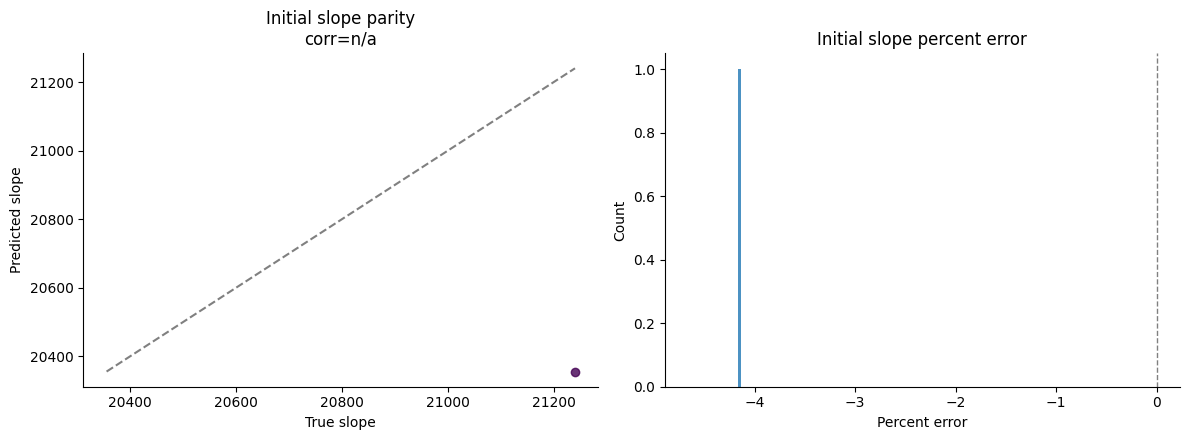

### Worst Initial Slope Samples

,sample,true_slope,pred_slope,slope_error,slope_percent_error,abs_percent_error
0,0,21240.059828,20356.020894,-884.038934,-4.16213,4.16213


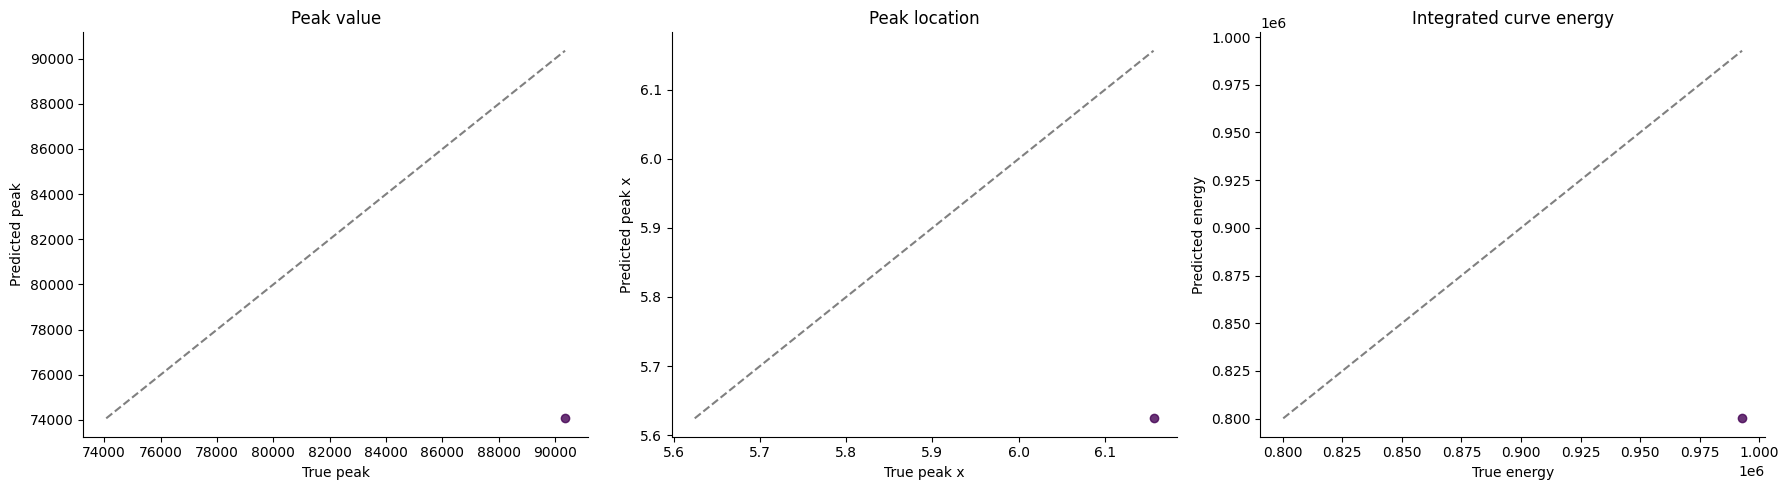

In [76]:
SHOW_INITIAL_SLOPE = True
INITIAL_SLOPE_WINDOW_FRACTION = 0.08
INITIAL_SLOPE_X_THRESHOLD = None
INITIAL_SLOPE_MIN_POINTS = 3
INITIAL_SLOPE_TOP_N = 5
SHOW_PEAK_ENERGY = True


if SHOW_INITIAL_SLOPE:
    slope_metrics_df, slope_summary = display_curve_initial_slope_summary(
        active_diag,
        window_fraction=INITIAL_SLOPE_WINDOW_FRACTION,
        x_threshold=INITIAL_SLOPE_X_THRESHOLD,
        min_points=INITIAL_SLOPE_MIN_POINTS,
        top_n=INITIAL_SLOPE_TOP_N,
    )

if SHOW_PEAK_ENERGY:
    display_curve_peak_energy_summary(active_diag)


## 11. Zone Metrics


### Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,85,0.000000,6.384385,5825.807666,6.271683e+07,7919.395996,-5825.801395,0.0,0.0,0.0
1,peak_region,85,160,6.460397,12.084379,17407.608434,3.835666e+08,19584.856053,-17389.268682,0.0,0.0,0.0
2,post_peak,160,201,12.160392,15.200355,17948.675201,3.589186e+08,18945.146799,-17948.675201,0.0,0.0,0.0


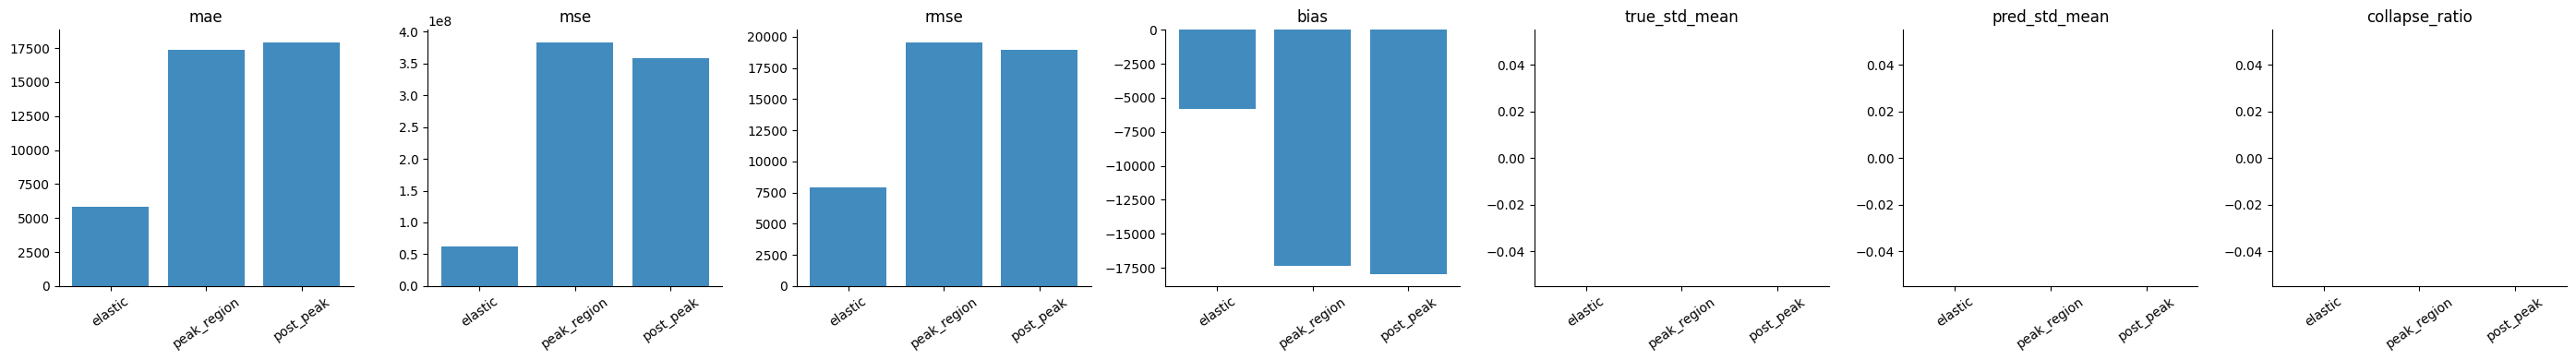

In [77]:
SHOW_ZONE_METRICS = True


if SHOW_ZONE_METRICS:
    display_curve_zone_summary(active_diag)


## 12. Selected Curve Examples


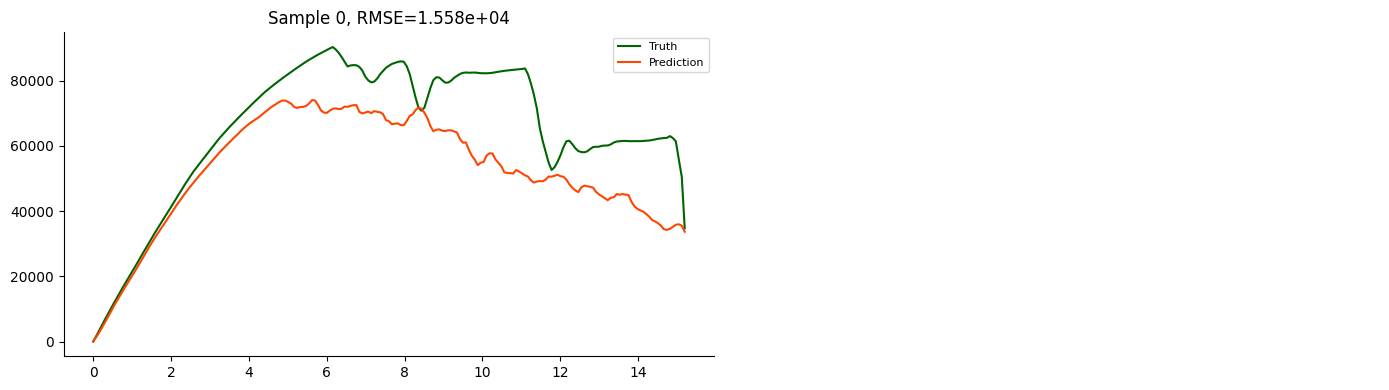

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Sample 0, RMSE=1.558e+04'}>, <Axes: >],
       dtype=object))

In [78]:
SELECTED_SAMPLE = 0
RANDOM_SAMPLE_COUNT = 8
RANDOM_SEED = 42
EXAMPLE_RANK_BY = "sample_rmse"
EXAMPLE_NCOLS = 2


display_curve_sample_examples(
    active_diag,
    selected_sample=SELECTED_SAMPLE,
    random_count=RANDOM_SAMPLE_COUNT,
    random_seed=RANDOM_SEED,
    rank_by=EXAMPLE_RANK_BY,
    ncols=EXAMPLE_NCOLS,
)


## 13. Training Loss History


,mode,epoch,train_loss,val_loss
0,FT,1,44.706140,7.247818
1,FT,2,9.453340,6.416992
2,FT,3,6.259025,5.984782
3,FT,4,5.141224,5.879558
4,FT,5,4.611404,5.720411


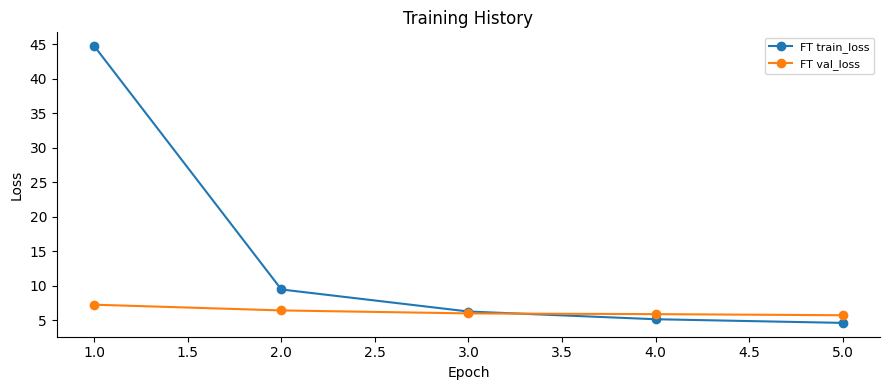

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Training History'}, xlabel='Epoch', ylabel='Loss'>)

In [79]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)


## 14. Loss Component Breakdown


In [80]:
SHOW_LOSS_COMPONENTS = True


if SHOW_LOSS_COMPONENTS:
    loss_components_df = display_curve_loss_component_breakdown(MOD, active_diag, active_key=active_key)


MODEL is not loaded, so loss components cannot be evaluated.
